# 05. LangGraph 챗봇 구축

> 앞서 배운 StateGraph 개념을 합쳐 첫 챗봇을 만들어요. `add_messages` 리듀서로 대화 이력을 누적하고 `stream()` 으로 실시간 응답까지 출력하는 흐름을 한 번에 경험해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `TypedDict`와 `Annotated`를 사용해서 LangGraph 상태(State)를 정의할 수 있어요
2. `add_messages` 리듀서가 메시지를 '덮어쓰지 않고 추가'하는 원리를 설명할 수 있어요
3. StateGraph에 노드(Node)와 엣지(Edge)를 추가하고 `compile()`로 실행 가능한 그래프를 만들 수 있어요
4. `stream()` 메서드로 챗봇의 응답을 실시간으로 출력할 수 있어요

## 사전 지식

- 이전 노트북 `04-StateGraph-Basics.ipynb`에서 배운 StateGraph, State, Node, Edge, START/END 개념
- `init_chat_model()` 기반 LLM 초기화 방법 (Part 2 - 02-Models 참고)
- Python `TypedDict`와 `Annotated` 타입 힌트 기본 이해


## LangGraph 챗봇의 구조

이전 노트북에서 StateGraph, Node, Edge의 기본 구성 요소를 배웠어요. 이제 그 구성 요소에 **실제 LLM을 연결**해서 대화가 가능한 챗봇을 만들어볼 거예요. LangGraph로 챗봇을 만드는 건 의외로 간단해요. 핵심은 **상태(State)에 메시지를 쌓아가는 구조**예요.

사용자 질문이 들어오면 `chatbot` 노드가 LLM을 호출하고, 응답을 상태에 추가해요. `add_messages` 리듀서 덕분에 메시지 히스토리가 자동으로 누적됩니다.

> 🔑 **핵심 개념**: LangGraph의 챗봇은 '상태 기계(State Machine)'예요. 상태(State)를 공유하는 노드들이 순서에 따라 실행되면서 대화가 진행돼요.

### 전체 아키텍처

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"]) --> S
    S(["__start__"]) --> C
    C["chatbot 노드<br>LLM 호출"] --> E
    E(["__end__"]) --> R(["응답 출력<br>Response"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U,S input
    class C process
    class E,R output
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 코드 |
|-----------|------|------|
| **State** | 그래프 전체가 공유하는 데이터 구조 | `class State(TypedDict)` |
| **add_messages** | 메시지 추가 전용 리듀서 | `Annotated[list, add_messages]` |
| **chatbot 노드** | LLM을 호출하는 핵심 함수 | `def chatbot(state: State)` |
| **StateGraph** | 전체 그래프 빌더 | `StateGraph(State)` |
| **compile()** | 그래프를 실행 가능 형태로 변환 | `graph_builder.compile()` |


## 환경 설정


In [1]:
# API 키를 환경변수로 관리하기 위한 설정
from dotenv import load_dotenv

# .env 파일에서 API 키 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적 설정 (선택사항 - 실행 흐름을 LangSmith에서 시각화할 수 있어요)
import os

# LangSmith 추적 활성화: "true"로 설정하면 실행 로그가 LangSmith에 기록돼요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-05-ChatBot"


## 1. 챗봇을 7단계로 구축하기

LangGraph 챗봇을 구축하는 과정을 7단계로 나누어 살펴볼게요. 각 단계는 State, Node, Edge, Graph와 직접 연결되어 있으니 순서대로 따라가며 이해하는 걸 권장해요.

### STEP 1. 상태(State) 정의

LangGraph에서 **상태(State)**는 그래프의 모든 노드가 공유하는 데이터 구조예요. `TypedDict`를 사용해서 정의하며, 각 노드는 이 상태를 읽고 업데이트할 수 있어요.

`messages` 필드는 `Annotated` 타입과 `add_messages` 리듀서를 사용해서 정의해요.


In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages  # 메시지 누적 리듀서

# 챗봇을 위한 State 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

/Users/mhso/working/lecture/hankyung/01-langgraph/.venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### STEP 2. 노드(Node) 정의

노드(Node)는 그래프에서 실제 작업을 수행하는 단위예요. 보통 Python 함수로 정의하며, 현재 상태(State)를 입력으로 받아 처리하고 업데이트된 상태를 반환해요.

챗봇 노드 함수는 상태에서 메시지를 읽어 LLM에 전달하고, LLM의 응답을 새 메시지로 반환해요. 반환된 메시지는 `add_messages` 리듀서에 의해 기존 메시지 목록에 자동으로 추가돼요.


In [4]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("openai:gpt-4o-mini")

def chatbot(state: State):
    """챗봇 노드 함수
    
    현재 상태의 메시지를 LLM에 전달한다.
        현재 상태의 메시지 : Human - AI - Human - AI ...
    
    Args:
        state: 현재 그래프의 상태 ( 대화 내역 )

    Returns:
        업데이트 된 상태 딕셔너리 : 사람의 프롬프트에 의한 AI의 응답이 업데이트
    """
    return {"messages": [ llm.invoke(state['messages']) ]}

### STEP 3. 그래프(Graph) 정의와 노드 추가

`StateGraph`는 LangGraph의 핵심 클래스로, 상태 기반 워크플로우를 정의해요. 정의한 `State` 타입을 인자로 전달해서 그래프 빌더를 생성해요.

`add_node()` 메서드로 그래프에 노드를 추가해요. 첫 번째 인자는 노드 이름(문자열)이고, 두 번째 인자는 실행될 함수예요.


In [5]:
builder = StateGraph(State)

builder.add_node("chatbot", chatbot)

### STEP 4. 엣지(Edge) 추가

엣지(Edge)는 노드와 노드를 연결해서 그래프의 실행 흐름을 정의해요. LangGraph는 `START`와 `END` 두 가지 특수 노드를 제공해요.

- `START`: 그래프 실행의 진입점 — 처음으로 실행될 노드를 지정해요
- `END`: 그래프 실행의 종료점 — 더 이상 실행할 노드가 없음을 나타내요


In [6]:
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

### STEP 5. 그래프 컴파일(compile)

`StateGraph`를 정의한 후에는 반드시 `compile()` 메서드를 호출해서 실행 가능한 형태로 변환해야 해요. 컴파일 과정에서 노드 간 연결이 검증되고 실행 순서가 결정돼요.

`compile()`을 건물의 **준공 검사**에 비유할 수 있어요. 설계도(StateGraph)를 그리고 자재를 배치(add_node, add_edge)한 뒤, 모든 연결이 올바른지 최종 점검하는 단계예요. 준공 검사를 통과해야 건물에 입주(invoke/stream)할 수 있는 것처럼, `compile()` 없이는 그래프를 실행할 수 없어요.

컴파일된 그래프는 `invoke()` 또는 `stream()` 메서드를 통해 실행할 수 있어요.


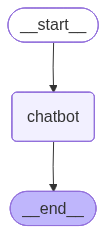

In [7]:
graph = builder.compile()
graph

### STEP 6. 그래프 시각화

컴파일된 그래프를 시각화해서 노드 간 연결 관계와 실행 흐름을 직관적으로 확인해볼게요.

복잡한 그래프를 디버깅하거나 구조를 검토할 때 매우 유용한 기능이에요.


In [ ]:
from IPython.display import Image, display

# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: 그래프 흐름: START → chatbot → END
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.


### STEP 7. 그래프 실행

이제 챗봇을 실행해볼게요! `stream()` 메서드를 사용하면 응답을 실시간으로 받을 수 있어요.

입력은 딕셔너리 형태로 전달하며, `messages` 키에 사용자 메시지 튜플 `("user", 질문내용)`을 리스트로 감싸서 전달해요.


In [10]:
question = "서울의 유명한 맛집 TOP 5 추천해줘"
inputs = {"messages": [("user", question)]}

# result = graph.invoke(inputs)
# result

for chunk in graph.stream(inputs, stream_mode='updates'):
    for node_name, node_output in chunk.items():
        print(f"\n=====노드 이름 : {node_name}=====")

        # 메시지가 있으면 출력
        if "messages" in node_output:
            for msg in node_output['messages']:
                msg.pretty_print()


=====노드 이름 : chatbot=====
================================== Ai Message ==================================

서울에는 다양한 맛집이 많습니다. 다음은 서울에서 유명한 맛집 TOP 5 추천 목록입니다:

1. **광장시장** - 전통 시장으로, 다양한 한국 길거리 음식을 맛볼 수 있습니다. 특히 빈대떡, 마늘빵, 떡볶이 등이 유명합니다.

2. **백리향** - 서울의 대표적인 중식당 중 하나로, 정통 중국 요리를 제공합니다. 특히 딤섬과 짜장면이 인기입니다.

3. **동태집** - 신선한 동태(대구) 요리를 전문으로 하는 집으로, 특히 동태찌개와 동태전이 유명합니다. 소박하지만 맛이 뛰어난 한국 전통 음식입니다.

4. **고기리 막국수** - 막국수 전문점으로, 직접 만든 면과 신선한 재료로 만든 냉면을 제공합니다. 여름철에 특히 인기 있는 곳입니다.

5. **부암동 카페거리** - 멋진 경치를 즐기면서 다양한 디저트와 음료를 맛볼 수 있는 카페들이 모여 있는 지역입니다. 특히 빵과 커피가 맛있기로 유명합니다.

각 맛집마다 특별한 메뉴와 분위기가 있으니 방문하셔서 다양한 맛을 즐겨보세요!


## 2. add_messages 리듀서 심층 이해

챗봇의 핵심인 `add_messages` 리듀서가 실제로 어떻게 작동하는지 직접 확인해볼게요.

> 🔑 **핵심 개념**: 일반적인 딕셔너리 업데이트는 기존 값을 **덮어써요**(`state["messages"] = 새 메시지`). 하지만 `add_messages` 리듀서는 새 메시지를 기존 목록에 **추가해요**(`state["messages"] += [새 메시지]`). 이 차이가 대화 히스토리 유지의 핵심이에요.

### 비유: 칠판 vs 노트

리듀서가 없는 일반 필드는 **칠판**과 같아요. 새로운 내용을 쓰면 이전 내용이 지워져요. 반면 `add_messages` 리듀서가 적용된 필드는 **노트**와 같아요. 새로운 내용을 쓰면 이전 페이지 뒤에 이어서 기록돼요. 대화 히스토리는 이전 내용이 사라지면 안 되니까, 반드시 "노트" 방식(`add_messages`)을 써야 해요.

| 방식 | 비유 | 동작 | 예시 |
|------|------|------|------|
| 일반 필드 (리듀서 없음) | 칠판 | 덮어쓰기 | `messages = [새 메시지]` (이전 대화 사라짐) |
| `add_messages` 리듀서 | 노트 | 이어쓰기 | `messages += [새 메시지]` (이전 대화 유지) |


In [11]:
result = graph.invoke({"messages": [("user", "파이썬이란 무엇인가요? 한 문장으로 답해주세요.")]})

# 최종 상태의 messages 목록:
print(f"총 메시지 수: {len(result['messages'])}개")
print()

# 메시지 목록을 순서대로 출력해요
for i, msg in enumerate(result["messages"]):
    print(f"[{i+1}] 타입: {msg.type}")
    # 내용이 길면 200자까지만 출력해요
    content_preview = msg.content[:200] if len(msg.content) > 200 else msg.content
    print(f"    내용: {content_preview}")
    print()

총 메시지 수: 2개

[1] 타입: human
    내용: 파이썬이란 무엇인가요? 한 문장으로 답해주세요.

[2] 타입: ai
    내용: 파이썬은 쉽고 직관적인 문법을 가진 고급 프로그래밍 언어로, 다양한 분야에서 개발에 사용됩니다.



## 3. 스트리밍 출력 모드 비교

LangGraph의 `stream()` 메서드는 두 가지 주요 모드를 지원해요. 각각의 차이를 이해하면 필요에 맞게 선택할 수 있어요.

| 모드 | 반환 내용 | 사용 시점 |
|------|-----------|----------|
| `stream_mode="updates"` | 각 노드가 반환한 **업데이트 내용만** | 어떤 노드가 무엇을 변경했는지 추적할 때 |
| `stream_mode="values"` | 각 단계 후의 **전체 상태** | 실행 중간 상태를 전부 확인할 때 |


In [12]:
for snapshot in graph.stream( {"messages": [("user", "LangGraph가 뭔지 두 줄로 설명해줘")]}, stream_mode="values"):
    # snapshot은 현재 시점의 전체 State 딕셔너리예요
    print(f"\n현재 상태 messages 수: {len(snapshot['messages'])}개")
    # 마지막 메시지만 출력해요
    snapshot["messages"][-1].pretty_print()


현재 상태 messages 수: 1개
================================ Human Message =================================

LangGraph가 뭔지 두 줄로 설명해줘

현재 상태 messages 수: 2개
================================== Ai Message ==================================

LangGraph는 자연어 처리(NLP)와 그래프 데이터 구조를 결합한 모델로, 텍스트 데이터에서 의미적 관계를 추출하고 분석하는 데 사용됩니다. 이를 통해 언어 이해 및 생성 작업에서 성능을 향상시킬 수 있습니다.


## 4. 전체 코드 통합

앞서 7단계로 나누어 살펴본 코드를 하나의 셀로 정리했어요. 처음부터 다시 실행하거나 새 환경에서 시작할 때 이 셀을 사용하면 돼요.


In [ ]:
# ---------------------------------------------------
# LangGraph 챗봇 전체 코드 (통합본)
# ---------------------------------------------------
from typing import Annotated, TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from IPython.display import Image, display


# STEP 1. 상태(State) 정의
class State(TypedDict):
    # add_messages 리듀서: 메시지를 덮어쓰지 않고 추가(append)해요
    messages: Annotated[list, add_messages]


# STEP 2. 노드(Node) 정의
# 기본 모델: gpt-4o-mini
llm = init_chat_model("openai:gpt-4o-mini")


def chatbot(state: State):
    """챗봇 노드: 현재 메시지를 LLM에 전달하고 응답을 반환해요"""
    return {"messages": [llm.invoke(state["messages"])]}


# STEP 3. 그래프 빌더 생성 및 노드 추가
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

# STEP 4. 엣지 추가
graph_builder.add_edge(START, "chatbot")  # 시작 → chatbot
graph_builder.add_edge("chatbot", END)    # chatbot → 종료

# STEP 5. 컴파일
graph = graph_builder.compile()

# STEP 6. 시각화
# 그래프 흐름: START → chatbot → END
# chatbot 노드: LLM이 사용자 메시지를 받아 응답을 생성해요
display(Image(graph.get_graph().draw_mermaid_png()))

# STEP 7. 실행
question = "인공지능이란 무엇인가요? 간단하게 설명해주세요."

print(f"질문: {question}")
# ==================================================

for chunk in graph.stream({"messages": [("user", question)]}, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()

## 5. 실습: 나만의 챗봇 만들기

아래 TODO 블록에서 시스템 프롬프트를 추가해서 특정 역할을 가진 챗봇을 만들어보세요.

`SystemMessage`를 메시지 목록에 추가하면 챗봇의 역할을 지정할 수 있어요.


In [ ]:
from langchain.messages import SystemMessage


# ============================================================
# TODO: 아래에서 시스템 프롬프트를 수정해서 나만의 챗봇을 만들어보세요!
# 힌트: SYSTEM_PROMPT 문자열을 원하는 역할로 변경하면 돼요
#       예: "당신은 친절한 한국 역사 선생님이에요. 모든 답변은 한국어로 해주세요."
#       예: "당신은 파이썬 코딩 튜터예요. 코드 예제를 많이 사용해서 설명해주세요."
# 예상 결과: 시스템 프롬프트에 정의된 역할대로 챗봇이 응답해요
# ============================================================


# TODO: 질문도 원하는 내용으로 바꿔보세요!


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **State 정의**: `TypedDict`와 `Annotated[list, add_messages]`를 사용해서 메시지 누적 상태를 정의했어요
- **add_messages 리듀서**: 새 메시지가 기존 메시지를 덮어쓰지 않고 추가(append)되어 대화 히스토리가 유지돼요
- **chatbot 노드**: `state["messages"]`를 LLM에 전달하고 응답을 반환하는 함수로 노드를 정의했어요
- **그래프 구성**: `add_node()`, `add_edge()`, `compile()` 순서로 실행 가능한 StateGraph를 만들었어요
- **stream() 실행**: `stream_mode="updates"`와 `"values"` 두 가지 스트리밍 모드의 차이를 이해했어요
- **시스템 프롬프트**: `SystemMessage`를 메시지 목록에 추가하면 챗봇의 역할을 지정할 수 있어요


## 다음 노트북 예고

다음 `06-Tools-Integration.ipynb`에서는 **Tool Binding, ToolNode, tools_condition**을 배워요.

지금까지 만든 챗봇은 LLM이 아는 지식만 대답할 수 있었어요. 다음 노트북에서는 웹 검색, 계산기 같은 외부 도구를 챗봇에 연결해서 실제 세계와 상호작용하는 에이전트를 만들어볼 거예요!
